In [19]:
%load_ext autoreload
%autoreload 2
import sisl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.spatial import cKDTree
from ase.visualize.plot import plot_atoms
from tqdm.auto import tqdm


from mytools.scalingv2 import get_centers, get_corners, get_edges, get_fractional
from mytools.scalingv2 import rsse_to_edge, rsse_mapping, map_edges, map_corners, extrapolate
from mytools.construct import make_edge, all_armchair
from mytools.plots import thesis_fig


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
BOND = 1.42
phi = np.pi/3
B = BOND*np.cos(phi/2)

N0 = 4
N_small = 6
N_big = 6

R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

ETA = 1e-3
NUMK = 400

In [30]:
graphene6 = all_armchair(BOND)

Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

# Make the edges and RSSE

In [31]:
rsse_small = sisl.RealSpaceSE(Ham0, 0, 1, (N_small, N_small, 1))
rsse_small.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))

rsse_big = sisl.RealSpaceSE(Ham0, 0, 1, (N_big, N_big, 1))
rsse_big.setup(eta=ETA, 
            bz=sisl.MonkhorstPack(Ham0, [1, NUMK, 1]))


In [32]:
def resub_ham(rsse):
    Ham_rs, elec_idx = rsse.real_space_coupling(ret_indices=True)
    Ham_NN = rsse.real_space_parent()
    all_idx = np.arange(Ham_NN.na)
    device_idx = np.delete(all_idx, elec_idx)
    sub_idx = np.concat([elec_idx, device_idx])
    Ham_NN_re = Ham_NN.sub(sub_idx)
    
    out = {
        "H_elec": Ham_rs,
        "elec_idx": elec_idx,
        "sub_idx": sub_idx,
        
    }
    return Ham_NN_re, out

In [33]:
Ham_reord_small, d_small = resub_ham(rsse_small)
Ham_reord_big, d_big = resub_ham(rsse_big)

elec_idx_small = d_small['elec_idx']
elec_idx_big = d_big['elec_idx']

H_elec_small = d_small['H_elec']
H_elec_big = d_big["H_elec"]

sub_idx_small = d_small['sub_idx']
sub_idx_big = d_big['sub_idx']

In [34]:
rsse_re_coord_small = H_elec_small.xyz - H_elec_small.center()
rsse_re_coord_big = H_elec_big.xyz - H_elec_big.center()


In [35]:
geom_edge_small = make_edge(graphene6, N_small, N_small)
geom_edge_big = make_edge(graphene6, N_big, N_big)

In [37]:
NC = 1
na = Ham0.na
corners_small = get_corners(N_small, N_small, na=na, NC=NC)
corners_big = get_corners(N_big, N_big, na=na, NC=NC)

edges_small = get_edges(N_small, N_small, na=na, NC=NC)
edges_big = get_edges(N_big, N_big, na=na, NC=NC)

_, small_to_big_idx = map_edges(geom_edge_small, geom_edge_big, N_small, N_big, Ham0.na, NC=NC)
print(small_to_big_idx)

[0 1 2 3 4 5 6 7]


In [38]:
geom_edge_big.plot(axes="xy",
                     atoms_style=[
                         dict(atoms=corners_big, color="red"),
                         dict(atoms=edges_big, color="lime"),
                     ])

In [39]:
def distinct_colors(n):
    hues = np.linspace(0, 1 , n, endpoint=False)
    return [mcolors.hsv_to_rgb([h, 0.85, 0.85]) for h in hues]


def outward_offset(xyz_centered, scale=0.5):
    """Unit outward normal from center for each atom, scaled."""
    norms = np.linalg.norm(xyz_centered[:, :2], axis=1, keepdims=True)
    unit_outward = xyz_centered[:, :2] / norms          # (N, 2)
    return unit_outward * scale   

centroids_edge_small = get_centers(geom_edge_small.xyz[edges_small], Ham0.na) - geom_edge_small.center()
centroids_edge_big = get_centers(geom_edge_big.xyz[edges_big], Ham0.na) - geom_edge_big.center()
n_small = len(centroids_edge_small)
colors = np.asarray(distinct_colors(n_small))


xyz_small_centered = geom_edge_small.xyz - geom_edge_small.center()
xyz_big_centered = geom_edge_big.xyz - geom_edge_big.center()

19.67609717398246


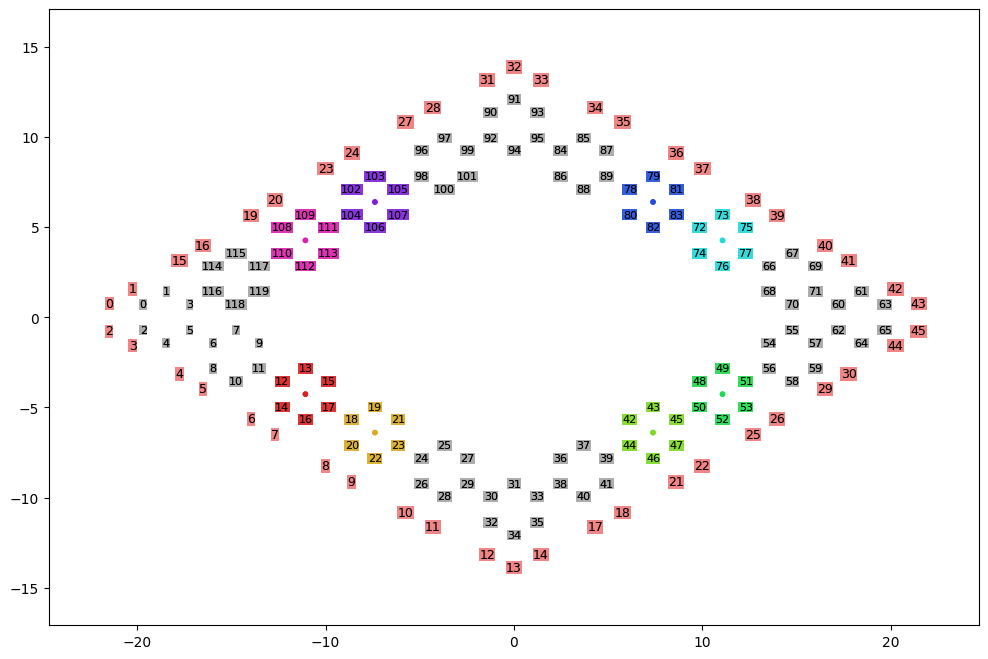

In [40]:
fig, ax = plt.subplots(figsize=(12,8))
# fig, ax = thesis_fig()

# centroids — already vectorised via scatter
cx, cy, _ = centroids_edge_small.T
ax.scatter(cx, cy, color=colors, marker=".", zorder=3)


for (atom_idx, (x,y,_)) in zip(corners_small, xyz_small_centered[corners_small]):
    ax.text(x,y,atom_idx,ha="center",va="center",fontsize=8,
            bbox=dict(facecolor="grey", alpha=0.4, pad=0.2, edgecolor="none")
    )

# repeat colors for number of atoms per centroid and color the atom idices by centroid it belongs to
colors_repeated_small = np.repeat(colors, Ham0.na, axis=0)
# colored text boxes for atom index belogning to centroid of same color
for (i, (atom_idx, (x,y,_))) in enumerate(zip(edges_small, xyz_small_centered[edges_small])):
    ax.text(x,y,atom_idx,ha="center",va="center",fontsize=8,
        bbox=dict(facecolor=colors_repeated_small[i], alpha=0.7, pad=0.2, edgecolor="none")
    )
    

# plot the centroids of the big structure by the color of the corresponding smaller structure
cx,cy,_ = centroids_edge_big.T
ax.scatter(cx,cy, color=colors[small_to_big_idx], marker=".", zorder=3)

for (atom_idx, (x,y,_)) in zip(corners_big, xyz_big_centered[corners_big]):
    ax.text(x,y,atom_idx,ha="center",va="center",fontsize=8,
            bbox=dict(facecolor="grey", alpha=0.4, pad=0.2, edgecolor="none")
    )

# repeat colors (indexed to number of centroids belogning to each centroid in small) by the number of atoms per centroid in big structre
colors_repeated_big = np.repeat(colors[small_to_big_idx], Ham0.na, axis=0)
# color text boxes for atom index belogning to centroid of same color
for (i, (atom_idx, (x,y,_))) in enumerate(zip(edges_big, xyz_big_centered[edges_big])):
    ax.text(x,y,atom_idx,ha="center",va="center",fontsize=8,
        bbox=dict(facecolor=colors_repeated_big[i], alpha=0.7, pad=0.2, edgecolor="none")
    )


offset_small = outward_offset(rsse_re_coord_small, scale=1.8)
offset_big = outward_offset(rsse_re_coord_big, scale=1.8)

for atom_idx, (x,y,_) in enumerate(rsse_re_coord_small):
    dx,dy = offset_small[atom_idx]
    ax.text(x+dx,y+dy,atom_idx,ha="center", va="center", fontsize=9,
            bbox=dict(facecolor="lightcoral", alpha=0.8, pad=0.2, edgecolor="None")
            )
    
for atom_idx, (x,y,_) in enumerate(rsse_re_coord_big):
    dx,dy = offset_big[atom_idx]
    ax.text(x+dx,y+dy,atom_idx,ha="center", va="center", fontsize=9,
            bbox=dict(facecolor="lightcoral", alpha=0.8, pad=0.2, edgecolor="None")
            )
    

plot_radii_x = np.max(xyz_big_centered[:, 0])
plot_radii_y = np.max(xyz_big_centered[:, 1])
print(plot_radii_x) 
ax.set(xlim=(-5-plot_radii_x, 5+plot_radii_x),
       ylim=(-5-plot_radii_y, 5+plot_radii_y),
       )

fig.savefig(f"../figures/show_extrapolation_-_{N_small}_to_{N_big}")

In [41]:
convert = rsse_mapping(H_elec_small, H_elec_big, geom_edge_small, geom_edge_big, N_small, N_big, Ham0.na, NC=NC, ret_parts=False)
convert[34]

34

In [42]:
r2_to_e2, e2_to_e1, e1_to_r1 = rsse_mapping(H_elec_small, H_elec_big, geom_edge_small, geom_edge_big, N_small, N_big, Ham0.na, NC=NC, ret_parts=True)

In [44]:
ir2 = 20
ie2 = r2_to_e2[ir2]
ie1 = e2_to_e1[ie2]
ir1 = e1_to_r1[ie1]

print("ir2 --> ie4 --> ie1 --> ir1")
print(" {} -->  {} -->  {} -->  {}".format(ir2, ie2, ie1, ir1))

ir2 --> ie4 --> ie1 --> ir1
 20 -->  109 -->  109 -->  20


In [45]:
#  sanity check
test = lambda ir2 : e1_to_r1[e2_to_e1[r2_to_e2[ir2]]]
for key in convert.keys():
    if  not (convert[key] == test(key)):
        print(f"key {key}: {convert[key]} vs {test(key)}")